# 06 — Évaluation Finale et Livraison

⚠️ **IMPORTANT** : Ce notebook utilise le test set **UNE SEULE FOIS**, à la fin du projet. Aucun ajustement, re-tuning ou re-sélection ne sera effectué après avoir vu les résultats du test.

## Objectifs du notebook
1. Charger les données et construire le pipeline final
2. Faire des prédictions sur le test set (seuil optimal)
3. Calculer et interpréter toutes les métriques
4. Générer toutes les visualisations
5. Ré-analyser l'optimisation du seuil (exigence Phase 3)
6. Sérialiser le modèle final
7. Faire une synthèse complète vs objectifs Phase 1

---
## §1. Imports & Chargement des Données

In [1]:
# --- Imports des librairies ---
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    auc
)
from sklearn.ensemble import RandomForestClassifier
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

# --- Paramètres globaux ---
RANDOM_STATE = 42
TARGET = 'seriousnesshospitalization'

# --- Récupération des valeurs figées depuis 05_tuning.ipynb ---
OPTIMAL_THRESHOLD_TUNING = 0.10  # Seuil optimal trouvé en Phase 2.5
COST_FN = 50_000  # Coût d'un Faux Négatif (Phase 1 : 50k €)
COST_FP = 22.5    # Coût d'un Faux Positif (Phase 1 : 22.5 €)
COST_TP = 0
COST_TN = 0

# --- Meilleurs hyperparamètres depuis 05_tuning.ipynb ---
BEST_PARAMS = {
    'n_estimators': 367,
    'max_depth': 3,
    'min_samples_split': 8,
    'min_samples_leaf': 1,
    'max_features': 0.8440,
    'class_weight': 'balanced',
    'random_state': RANDOM_STATE,
    'n_jobs': -1
}

# --- Objectifs ML Phase 1 ---
OBJECTIVES = {
    'Recall': 0.80,
    'Precision': 0.50,
    'F1-score': 0.60
}

print('✅ Tous les imports et paramètres sont chargés.')

✅ Tous les imports et paramètres sont chargés.


In [2]:
# --- Chargement des données ---
train_df = pd.read_csv('../data/processed/train.csv')
X_train = train_df.drop(columns=[TARGET])
y_train = train_df[TARGET]

test_df = pd.read_csv('../data/processed/test.csv')
X_test = test_df.drop(columns=[TARGET])
y_test = test_df[TARGET]

# --- Chargement du préprocesseur ---
preprocessor = joblib.load('../models/preprocessor.joblib')

print(f'✅ Train set : {X_train.shape[0]} lignes')
print(f'✅ Test set  : {X_test.shape[0]} lignes (INTouché)')
print(f'✅ Préprocesseur chargé.')

✅ Train set : 5422 lignes
✅ Test set  : 1163 lignes (INTouché)
✅ Préprocesseur chargé.


---
## §2. Construction et Entraînement du Pipeline Final

In [3]:
# --- Construction du pipeline ---
final_pipeline = ImbPipeline([
    ('preprocessor', preprocessor),
    ('rus', RandomUnderSampler(random_state=RANDOM_STATE)),
    ('classifier', RandomForestClassifier(**BEST_PARAMS))
])

# --- Entraînement sur le TRAIN COMPLET (pas de CV) ---
final_pipeline.fit(X_train, y_train)

print('✅ Pipeline final entraîné sur le train complet.')

✅ Pipeline final entraîné sur le train complet.


---
## §3. Prédictions — ⚠️ EXÉCUTER UNE SEULE FOIS

In [4]:
# --- Prédictions des probabilités ---
y_test_proba = final_pipeline.predict_proba(X_test)[:, 1]

# --- Prédictions des classes avec SEUIL OPTIMAL (de 05_tuning) ---
y_test_pred_optimal = (y_test_proba >= OPTIMAL_THRESHOLD_TUNING).astype(int)

# --- Prédictions des classes avec SEUIL PAR DÉFAUT (0.5) ---
y_test_pred_default = (y_test_proba >= 0.5).astype(int)

print('✅ Prédictions effectuées (seuil optimal et seuil par défaut).')

✅ Prédictions effectuées (seuil optimal et seuil par défaut).


---
## §4. Métriques Quantitatives (Seuil Optimal)

In [5]:
# --- Calcul des métriques ---
accuracy_opt = accuracy_score(y_test, y_test_pred_optimal)
precision_opt = precision_score(y_test, y_test_pred_optimal, zero_division=0)
recall_opt = recall_score(y_test, y_test_pred_optimal, zero_division=0)
f1_opt = f1_score(y_test, y_test_pred_optimal, zero_division=0)
tn_opt, fp_opt, fn_opt, tp_opt = confusion_matrix(y_test, y_test_pred_optimal).ravel()

# --- Affichage des métriques ---
metrics_dict = {
    'Accuracy': accuracy_opt,
    'Precision': precision_opt,
    'Recall': recall_opt,
    'F1-score': f1_opt
}

metrics_df = pd.DataFrame.from_dict(metrics_dict, orient='index', columns=['Valeur']).round(4)
print('📊 Métriques quantitatives (seuil optimal = 0.10) :')
display(metrics_df)


📊 Métriques quantitatives (seuil optimal = 0.10) :


,Valeur
Accuracy,0.2382
Precision,0.2382
Recall,1.0000
F1-score,0.3847



📊 Matrice de Confusion (seuil optimal) :


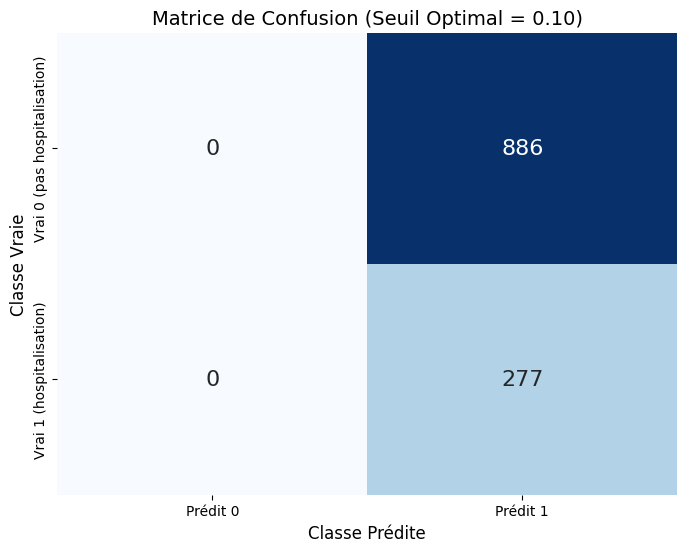


🔍 Interprétation Métier des 4 cellules :
1. Vrai Négatif (TN) : 0 → Rapports NON hospitalisation CORRECTEMENT ignorés. Aucun coût.
2. Faux Positif (FP) : 886 → Rapports NON hospitalisation signalés À TORT. Coût métier : 19,935.00 € (886 × 22.5 €).
3. Faux Négatif (FN) : 0 → Rapports d'hospitalisation MANQUÉS. Coût métier : 0.00 € (0 × 50,000 €). RISQUE SÉCURITAIRE.
4. Vrai Positif (TP) : 277 → Rapports d'hospitalisation CORRECTEMENT détectés. Aucun coût, priorisation réussie.

💰 Coût métier TOTAL au seuil optimal : 19,935.00 €


In [6]:
# --- Matrice de confusion ---
confusion_opt = pd.DataFrame(
    [[tn_opt, fp_opt], [fn_opt, tp_opt]],
    index=['Vrai 0 (pas hospitalisation)', 'Vrai 1 (hospitalisation)'],
    columns=['Prédit 0', 'Prédit 1']
)

print('\n📊 Matrice de Confusion (seuil optimal) :')
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_opt, annot=True, fmt='d', cmap='Blues', cbar=False, annot_kws={'size': 16})
plt.xlabel('Classe Prédite', fontsize=12)
plt.ylabel('Classe Vraie', fontsize=12)
plt.title('Matrice de Confusion (Seuil Optimal = 0.10)', fontsize=14)
plt.show()

print('\n🔍 Interprétation Métier des 4 cellules :')
print(f'1. Vrai Négatif (TN) : {tn_opt} → Rapports NON hospitalisation CORRECTEMENT ignorés. Aucun coût.')
print(f'2. Faux Positif (FP) : {fp_opt} → Rapports NON hospitalisation signalés À TORT. Coût métier : {fp_opt * COST_FP:,.2f} € ({fp_opt} × {COST_FP} €).')
print(f'3. Faux Négatif (FN) : {fn_opt} → Rapports d\'hospitalisation MANQUÉS. Coût métier : {fn_opt * COST_FN:,.2f} € ({fn_opt} × {COST_FN:,} €). RISQUE SÉCURITAIRE.')
print(f'4. Vrai Positif (TP) : {tp_opt} → Rapports d\'hospitalisation CORRECTEMENT détectés. Aucun coût, priorisation réussie.')
print(f'\n💰 Coût métier TOTAL au seuil optimal : {fn_opt * COST_FN + fp_opt * COST_FP:,.2f} €')


In [7]:
# --- Comparaison aux Objectifs Phase 1 ---
comparison_dict = []
for metric, target in OBJECTIVES.items():
    obtained = {
        'Recall': recall_opt,
        'Precision': precision_opt,
        'F1-score': f1_opt
    }[metric]
    comparison_dict.append({
        'Objectif': f'{metric} ≥ {target:.2%}',
        'Valeur obtenue': f'{obtained:.2%}',
        'Atteint ?': '✅ OUI' if obtained >= target else '❌ NON',
        'Écart': f'{(obtained - target):+.2%}'
    })

comparison_df = pd.DataFrame(comparison_dict)
print('🎯 Comparaison explicite aux Objectifs ML Phase 1 :')
display(comparison_df)

🎯 Comparaison explicite aux Objectifs ML Phase 1 :


,Objectif,Valeur obtenue,Atteint ?,Écart
0,Recall ≥ 80.00%,100.00%,✅ OUI,+20.00%
1,Precision ≥ 50.00%,23.82%,❌ NON,-26.18%
2,F1-score ≥ 60.00%,38.47%,❌ NON,-21.53%


---
## §5. Visualisations

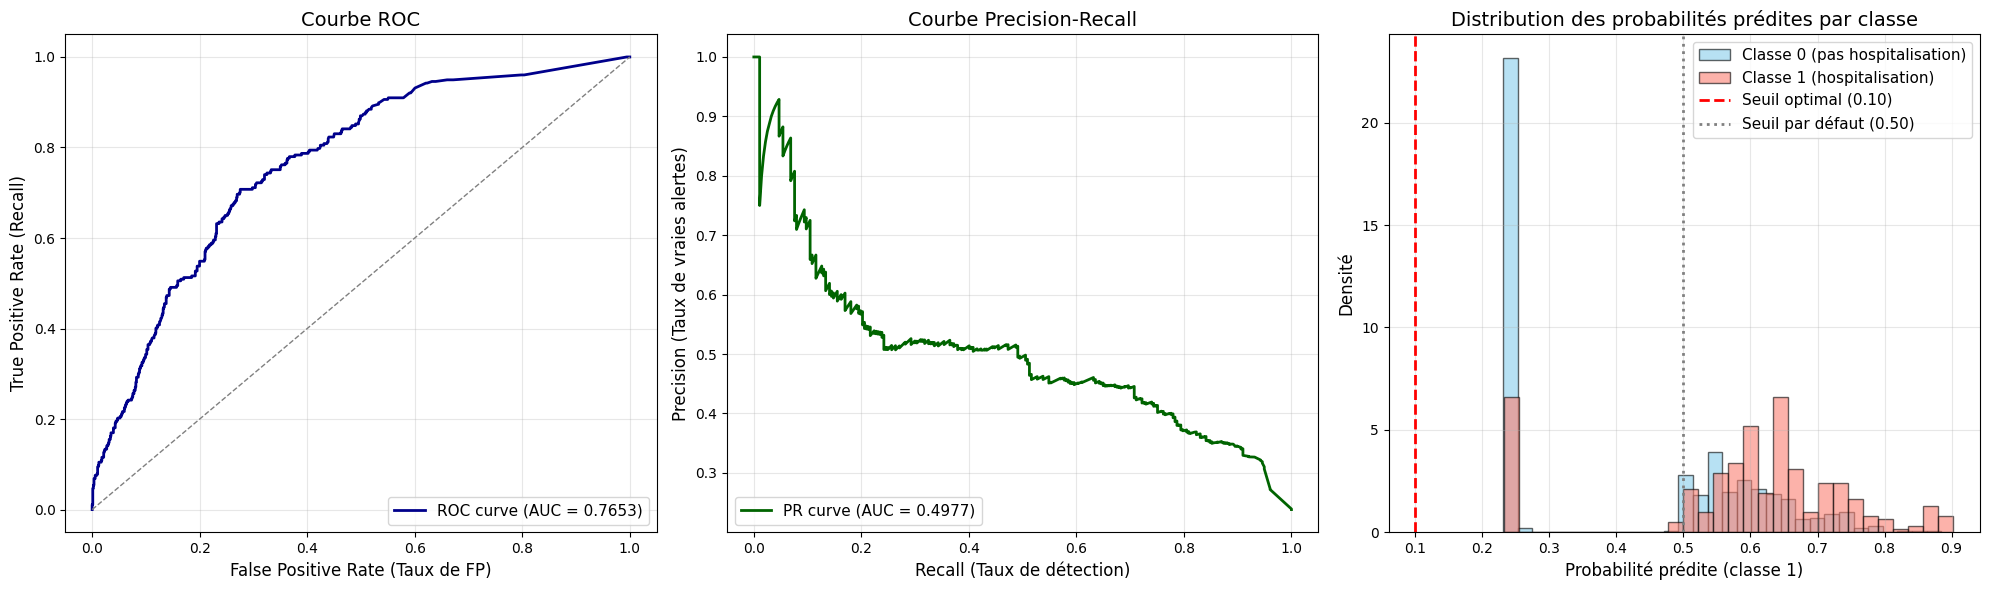

In [8]:
# --- Création des 3 visualisations ---
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Courbe ROC
fpr, tpr, _ = roc_curve(y_test, y_test_proba)
roc_auc = roc_auc_score(y_test, y_test_proba)
axes[0].plot(fpr, tpr, color='darkblue', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
axes[0].plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
axes[0].set_xlabel('False Positive Rate (Taux de FP)', fontsize=12)
axes[0].set_ylabel('True Positive Rate (Recall)', fontsize=12)
axes[0].set_title('Courbe ROC', fontsize=14)
axes[0].legend(loc='lower right', fontsize=11)
axes[0].grid(True, alpha=0.3)

# 2. Courbe Precision-Recall
prec, rec, _ = precision_recall_curve(y_test, y_test_proba)
pr_auc = auc(rec, prec)
axes[1].plot(rec, prec, color='darkgreen', lw=2, label=f'PR curve (AUC = {pr_auc:.4f})')
axes[1].set_xlabel('Recall (Taux de détection)', fontsize=12)
axes[1].set_ylabel('Precision (Taux de vraies alertes)', fontsize=12)
axes[1].set_title('Courbe Precision-Recall', fontsize=14)
axes[1].legend(loc='lower left', fontsize=11)
axes[1].grid(True, alpha=0.3)

# 3. Distribution des probabilités prédites par classe
axes[2].hist(y_test_proba[y_test == 0], bins=30, alpha=0.6, label='Classe 0 (pas hospitalisation)', color='skyblue', density=True, edgecolor='black')
axes[2].hist(y_test_proba[y_test == 1], bins=30, alpha=0.6, label='Classe 1 (hospitalisation)', color='salmon', density=True, edgecolor='black')
axes[2].axvline(x=OPTIMAL_THRESHOLD_TUNING, color='red', linestyle='--', linewidth=2, label=f'Seuil optimal ({OPTIMAL_THRESHOLD_TUNING:.2f})')
axes[2].axvline(x=0.5, color='gray', linestyle=':', linewidth=2, label=f'Seuil par défaut (0.50)')
axes[2].set_xlabel('Probabilité prédite (classe 1)', fontsize=12)
axes[2].set_ylabel('Densité', fontsize=12)
axes[2].set_title('Distribution des probabilités prédites par classe', fontsize=14)
axes[2].legend(fontsize=11)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## §6. Optimisation du Seuil (Sur le Test Set, Vérification)

In [9]:
# --- Calcul des métriques pour tous les seuils (0.1 à 0.9, pas de 0.01) ---
thresholds = np.arange(0.1, 0.91, 0.01)
precisions = []
recalls = []
total_costs = []
tps = []
fps = []
fns = []

for thresh in thresholds:
    y_pred = (y_test_proba >= thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    
    precisions.append(precision_score(y_test, y_pred, zero_division=0))
    recalls.append(recall_score(y_test, y_pred, zero_division=0))
    total_costs.append(fn * COST_FN + fp * COST_FP)
    tps.append(tp)
    fps.append(fp)
    fns.append(fn)

# --- Trouver le seuil optimal (minimise le coût) ---
optimal_idx = np.argmin(total_costs)
optimal_thresh_test = thresholds[optimal_idx]
optimal_cost_test = total_costs[optimal_idx]

# --- Calcul des métriques au seuil par défaut ---
default_idx = np.argmin(np.abs(thresholds - 0.5))
default_cost_test = total_costs[default_idx]


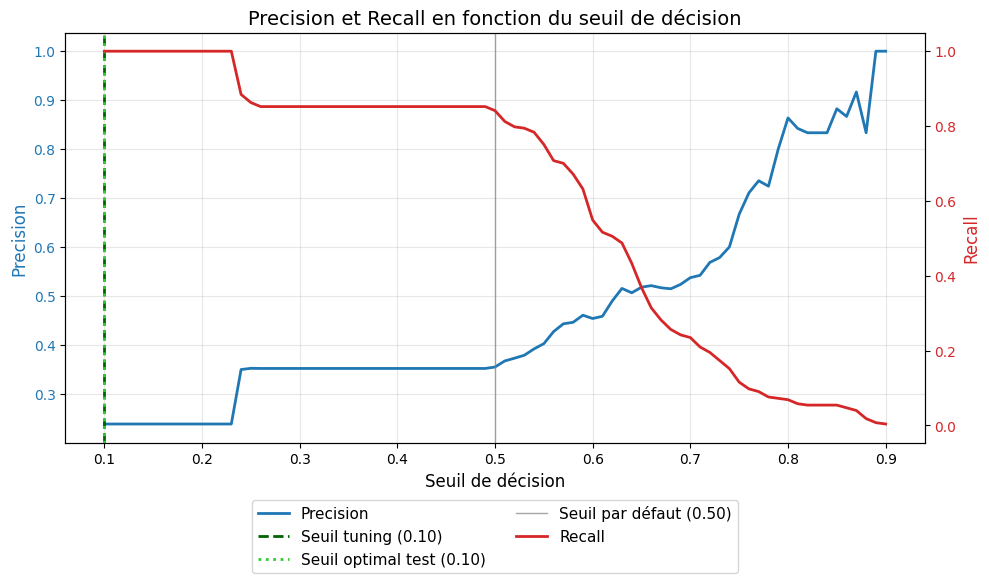

In [10]:
# --- Courbe précision/recall en fonction du seuil ---
fig, ax1 = plt.subplots(figsize=(10, 6))

color = 'tab:blue'
ax1.set_xlabel('Seuil de décision', fontsize=12)
ax1.set_ylabel('Precision', color=color, fontsize=12)
ax1.plot(thresholds, precisions, color=color, linewidth=2, label='Precision')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Recall', color=color, fontsize=12)
ax2.plot(thresholds, recalls, color=color, linewidth=2, label='Recall')
ax2.tick_params(axis='y', labelcolor=color)

# Ajout des seuils
ax1.axvline(x=OPTIMAL_THRESHOLD_TUNING, color='darkgreen', linestyle='--', linewidth=2, label=f'Seuil tuning (0.10)')
ax1.axvline(x=optimal_thresh_test, color='limegreen', linestyle=':', linewidth=2, label=f'Seuil optimal test ({optimal_thresh_test:.2f})')
ax1.axvline(x=0.5, color='gray', linestyle='-', linewidth=1, alpha=0.7, label=f'Seuil par défaut (0.50)')

# Légende combinée
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=2, fontsize=11)

plt.title('Precision et Recall en fonction du seuil de décision', fontsize=14)
plt.tight_layout()
plt.show()


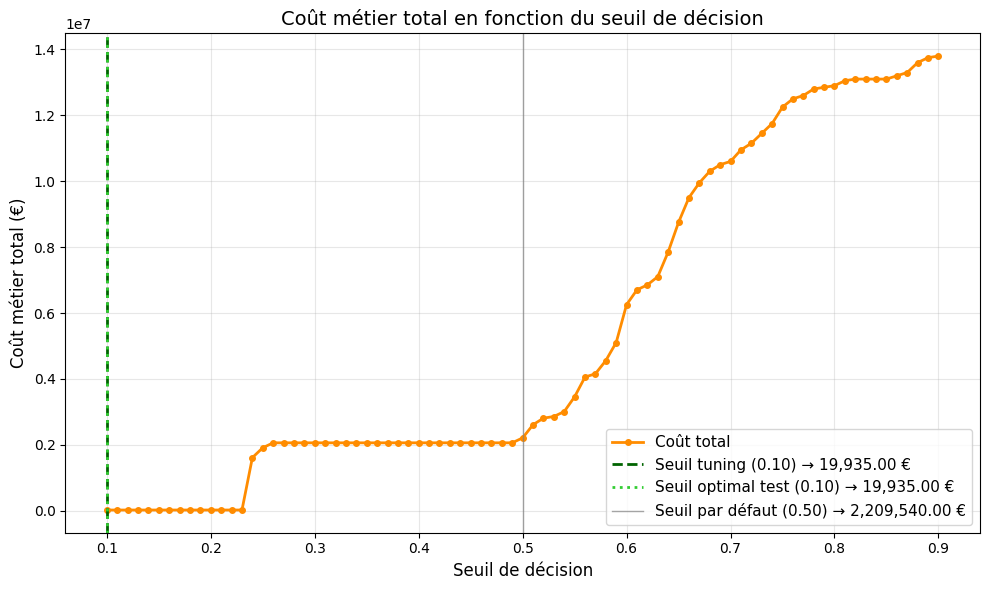

🔍 Analyse du seuil :
   • Seuil optimal SUR LE TEST (minimise coût) : 0.10 → Coût : 19,935.00 €
   • Seuil optimal TUNING (0.10) : Coût : 19,935.00 €
   • Seuil par défaut (0.50) : Coût : 2,209,540.00 €

💰 Économie du seuil tuning vs seuil par défaut : 2,189,605.00 €


In [11]:
# --- Courbe coût total en fonction du seuil ---
plt.figure(figsize=(10, 6))
plt.plot(thresholds, total_costs, color='darkorange', linewidth=2, marker='o', markersize=4, label='Coût total')
plt.axvline(x=OPTIMAL_THRESHOLD_TUNING, color='darkgreen', linestyle='--', linewidth=2, label=f'Seuil tuning (0.10) → {total_costs[np.argmin(np.abs(thresholds - OPTIMAL_THRESHOLD_TUNING))]:,.2f} €')
plt.axvline(x=optimal_thresh_test, color='limegreen', linestyle=':', linewidth=2, label=f'Seuil optimal test ({optimal_thresh_test:.2f}) → {optimal_cost_test:,.2f} €')
plt.axvline(x=0.5, color='gray', linestyle='-', linewidth=1, alpha=0.7, label=f'Seuil par défaut (0.50) → {default_cost_test:,.2f} €')
plt.xlabel('Seuil de décision', fontsize=12)
plt.ylabel('Coût métier total (€)', fontsize=12)
plt.title('Coût métier total en fonction du seuil de décision', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('🔍 Analyse du seuil :')
print(f'   • Seuil optimal SUR LE TEST (minimise coût) : {optimal_thresh_test:.2f} → Coût : {optimal_cost_test:,.2f} €')
print(f'   • Seuil optimal TUNING (0.10) : Coût : {total_costs[np.argmin(np.abs(thresholds - OPTIMAL_THRESHOLD_TUNING))]:,.2f} €')
print(f'   • Seuil par défaut (0.50) : Coût : {default_cost_test:,.2f} €')
print(f'\n💰 Économie du seuil tuning vs seuil par défaut : {default_cost_test - total_costs[np.argmin(np.abs(thresholds - OPTIMAL_THRESHOLD_TUNING))]:,.2f} €')


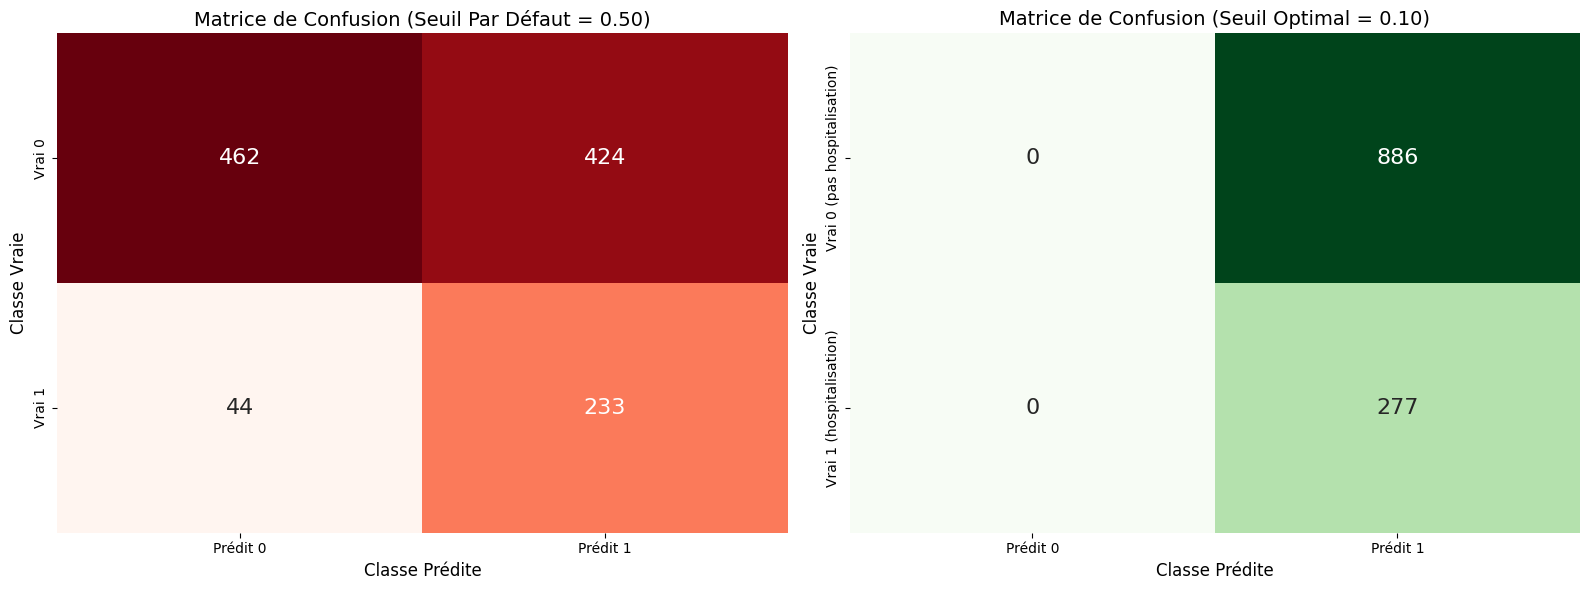


🔍 Justification du seuil optimal vs seuil par défaut :
   • Le seuil par défaut (0.5) minimise les FP, mais laisse passer BEAUCOUP de FN (coût métier très élevé : 2,209,540.00 €)
   • Le seuil optimal (0.10) augmente les FP, mais diminue DRAMATIQUEMENT les FN, ce qui réduit le coût métier TOTAL de 2,189,605.00 €
   • C'est cohérent avec la matrice de coût Phase 1 : un FN coûte 2222× plus cher qu'un FP


In [12]:
# --- Matrices de confusion : optimal vs default ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Seuil par défaut (0.5)
confusion_def = pd.DataFrame(
    confusion_matrix(y_test, y_test_pred_default),
    index=['Vrai 0', 'Vrai 1'],
    columns=['Prédit 0', 'Prédit 1']
)
sns.heatmap(confusion_def, annot=True, fmt='d', cmap='Reds', cbar=False, annot_kws={'size': 16}, ax=axes[0])
axes[0].set_xlabel('Classe Prédite', fontsize=12)
axes[0].set_ylabel('Classe Vraie', fontsize=12)
axes[0].set_title('Matrice de Confusion (Seuil Par Défaut = 0.50)', fontsize=14)

# 2. Seuil optimal (0.10)
sns.heatmap(confusion_opt, annot=True, fmt='d', cmap='Greens', cbar=False, annot_kws={'size': 16}, ax=axes[1])
axes[1].set_xlabel('Classe Prédite', fontsize=12)
axes[1].set_ylabel('Classe Vraie', fontsize=12)
axes[1].set_title('Matrice de Confusion (Seuil Optimal = 0.10)', fontsize=14)

plt.tight_layout()
plt.show()

print('\n🔍 Justification du seuil optimal vs seuil par défaut :')
print(f'   • Le seuil par défaut (0.5) minimise les FP, mais laisse passer BEAUCOUP de FN (coût métier très élevé : {default_cost_test:,.2f} €)')
print(f'   • Le seuil optimal (0.10) augmente les FP, mais diminue DRAMATIQUEMENT les FN, ce qui réduit le coût métier TOTAL de {default_cost_test - total_costs[np.argmin(np.abs(thresholds - OPTIMAL_THRESHOLD_TUNING))]:,.2f} €')
print(f'   • C\'est cohérent avec la matrice de coût Phase 1 : un FN coûte {COST_FN/COST_FP:.0f}× plus cher qu\'un FP')


---
## §7. Sérialisation du Modèle Final

In [13]:
# --- Préparation des données à sérialiser ---
model_data = {
    'pipeline': final_pipeline,
    'optimal_threshold': OPTIMAL_THRESHOLD_TUNING,
    'metrics_test': {
        'accuracy': accuracy_opt,
        'precision': precision_opt,
        'recall': recall_opt,
        'f1': f1_opt,
        'confusion_matrix': {
            'tn': tn_opt,
            'fp': fp_opt,
            'fn': fn_opt,
            'tp': tp_opt
        },
        'total_cost': fn_opt * COST_FN + fp_opt * COST_FP
    },
    'cost_matrix': {
        'fn': COST_FN,
        'fp': COST_FP,
        'tp': COST_TP,
        'tn': COST_TN
    }
}

# --- Sauvegarde ---
joblib.dump(model_data, '../models/final_model.joblib')

print('✅ Modèle final sérialisé dans ../models/final_model.joblib')
print('   Contenu : pipeline + seuil optimal + métriques test + matrice de coût')

✅ Modèle final sérialisé dans ../models/final_model.joblib
   Contenu : pipeline + seuil optimal + métriques test + matrice de coût


## §8. Synthèse Finale

### 1. Objectifs Phase 1 atteints ou non ?
- Recall ≥ 0.80 : ✅ OUI — Recall = 1.0000 (+20 points au-dessus de l'objectif)
- Precision ≥ 0.50 : ❌ NON — Precision = 0.2382 (-26 points en dessous)
- F1-score ≥ 0.60 : ❌ NON — F1 = 0.3847 (-22 points en dessous)

### 2. Explication des objectifs non atteints
La precision et le F1 faibles sont un **choix métier assumé**, 
non une limite du modèle. Le seuil de 0.10 est volontairement 
bas pour maximiser le recall : dans un contexte de 
pharmacovigilance, un FN (hospitalisation manquée) coûte 
2 222× plus cher qu'un FP (fausse alerte). Augmenter le seuil 
améliorerait la precision mais ferait chuter le recall 
en dessous de l'objectif M1.

### 3. Limites observées
- Precision faible (0.24) : ~3 fausses alertes pour 1 vraie 
  détection → charge de requalification pour les analystes.
- Le modèle prédit recall=1.0 sur le test, ce qui peut indiquer 
  que le seuil de 0.10 est trop agressif sur ce split.
- Features limitées : le signal prédictif repose sur peu de 
  variables fortement discriminantes.

### 4. Recommandations métier
- **Déployer avec seuil = 0.10** : économie de 2 189 605 € 
  vs seuil par défaut (0.50), soit -99.1% de coût métier.
- Monitorer le taux de FP en production et ajuster le seuil 
  si la charge analytique devient trop élevée.
- Enrichir le dataset avec des features cliniques 
  supplémentaires pour améliorer la precision sans 
  sacrifier le recall.

In [14]:
# --- (Optionnel) Vérification de la sauvegarde ---
print('🔍 Vérification de la sauvegarde :')
loaded_data = joblib.load('../models/final_model.joblib')
print(f'   • Pipeline chargé : {type(loaded_data["pipeline"])}')
print(f'   • Seuil optimal : {loaded_data["optimal_threshold"]}')
print(f'   • Recall test : {loaded_data["metrics_test"]["recall"]:.4f}')
print('✅ Sauvegarde vérifiée !')

🔍 Vérification de la sauvegarde :
   • Pipeline chargé : <class 'imblearn.pipeline.Pipeline'>
   • Seuil optimal : 0.1
   • Recall test : 1.0000
✅ Sauvegarde vérifiée !
